In [1]:
import numpy as np
import tifffile
from tqdm import tqdm
import matplotlib.pyplot as plt
from gpytoolbox import ray_triangle_intersect
import os
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [8]:
## Loading:

# Constants:
moon_radius = 1737.4  # km
earth_to_moon_dist = 384399 # km
num_gps_sats = 30
earth_ang = 0 # deg
gps_rad = 20180 #km
earth_rad = 6500 #km

# Image:
input_filename = "ldem_4.tif"
elev_km = tifffile.imread(input_filename)

# Image size:
img_width = elev_km.shape[1]
img_height = elev_km.shape[0]
print("Image Width =", img_width, "pixels, Image Height =", img_height, "pixels")

# Down sampling:
downsample_ratio = 20
downsample_elev = np.zeros((int(np.floor(img_height / downsample_ratio)), int(np.floor(img_width / downsample_ratio) )))
i0 = 0
j0 = 0
for i in range(img_width):
    if i % downsample_ratio == 0:
        for j in range(img_height):
            if j % downsample_ratio == 0:
                downsample_elev[j0][i0] = elev_km[j][i]
                j0 += 1
        j0 = 0
        i0 += 1

# Radius:
rad_map = downsample_elev + moon_radius
img_width = rad_map.shape[1]
img_height = rad_map.shape[0]
print("New Image Width =", img_width, "pixels, New Image Height =", img_height, "pixels")
print("Total pixel counts =", (img_width * img_height))
print(np.max(rad_map))

Image Width = 1440 pixels, Image Height = 720 pixels
New Image Width = 72 pixels, New Image Height = 36 pixels
Total pixel counts = 2592
1746.1140007019044


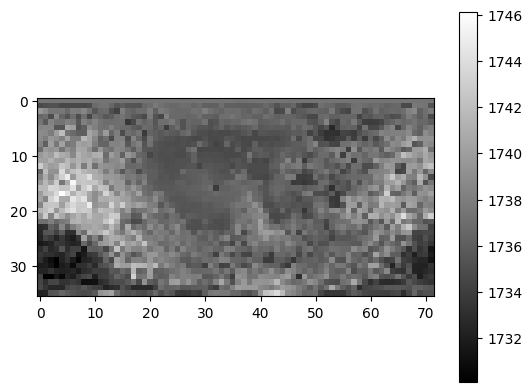

float64 (36, 72)
1746.1140007019044
1730.0939997673036
1737.4


In [9]:
## Confirm elevation map load is successful:
plt.imshow(rad_map, cmap="gray")
plt.colorbar()
plt.show()
print(rad_map.dtype, rad_map.shape)
print(rad_map.max())
print(rad_map.min())
print(rad_map[0][0])

In [10]:
def get_lat_lon(i,j):
    lon = (i * 1.0 / img_width) * 360 - 180
    lat = ((j+1) * 1.0 / (img_height+2)) * 180 - 90
    return lat, lon

def get_moon_pos(elev, i, j):
    if j == 0:
        return np.array([0, 0, -1 * np.mean(elev[:,0])])
    if j == img_height + 1:
        return np.array([0, 0, np.mean(elev[:,img_height-1])])
    lat_r, lon_r = np.deg2rad(get_lat_lon(i,j))
    print(lat_r, ",", lon_r, "-->",np.cos(lat_r))
    x = elev[j-1][i] * np.cos(lat_r) * np.cos(lon_r)
    y = elev[j-1][i] * np.cos(lat_r) * np.sin(lon_r)
    z = elev[j-1][i] * np.sin(lat_r) 
    print(z)
    return np.array([x, y, z])

def get_ij(i):
    if i == img_width * img_height:
        return i 
    return (i % img_height, int(np.floor(i / img_height)))

def get_index(i,j):
    if j == 0:
        return img_width * img_height
    if j == img_height+1:
        return img_width * img_height + 1
    #print(i, ",", j, " --> ", int(i * img_width + (j-1)))
    return int(i * img_height + (j-1))

In [11]:
## Make Sphere points
points = np.zeros((img_height * img_width + 2, 3))
for i in tqdm(range(img_width)):
    for j in range(img_height):
        print(j)
        pos = get_moon_pos(rad_map, i, j+1)
        #print(pos)
        points[get_index(i,j+1)][0] = pos[0]# np.vstack([points, ])
        points[get_index(i,j+1)][1] = pos[1]
        points[get_index(i,j+1)][2] = pos[2]
        #print(i, ", ", j, "-->", get_index(i,j+1))
        #print(get_moon_pos(rad_map, i, j))

north_pole = get_moon_pos(rad_map, 0, 0)
south_pole = get_moon_pos(rad_map, 0, img_height + 1)
points[img_height *img_width][0] = north_pole[0]
points[img_height *img_width][1] = north_pole[1]
points[img_height *img_width][2] = north_pole[2]
points[img_height *img_width + 1][0] = south_pole[0]
points[img_height *img_width + 1][1] = south_pole[1]
points[img_height *img_width + 1][2] = south_pole[2]
print(north_pole)
print(south_pole)

100%|██████████| 72/72 [00:00<00:00, 1770.26it/s]

0
-1.4054493450270127 , -3.141592653589793 --> 0.16459459028073398
-1713.7041285318899
1
-1.3227758541430708 , -3.141592653589793 --> 0.24548548714079924
-1681.6036155080465
2
-1.2401023632591288 , -3.141592653589793 --> 0.32469946920468357
-1645.2864518527974
3
-1.157428872375187 , -3.141592653589793 --> 0.40169542465296937
-1590.3168487472753
4
-1.0747553814912452 , -3.141592653589793 --> 0.47594739303707345
-1528.029356403111
5
-0.9920818906073031 , -3.141592653589793 --> 0.5469481581224269
-1455.331043017179
6
-0.9094083997233612 , -3.141592653589793 --> 0.6142127126896678
-1372.2206489942525
7
-0.8267349088394194 , -3.141592653589793 --> 0.677281571625741
-1279.239214029863
8
-0.7440614179554774 , -3.141592653589793 --> 0.7357239106731316
-1177.2782577419455
9
-0.6613879270715354 , -3.141592653589793 --> 0.7891405093963936
-1066.866905802752
10
-0.5787144361875936 , -3.141592653589793 --> 0.8371664782625285
-951.5246168424742
11
-0.4960409453036515 , -3.141592653589793 --> 0.87947

In [12]:
print(points.shape)
print(points[0])

(2594, 3)
[-2.85966641e+02 -3.50208132e-14 -1.71370413e+03]


In [13]:
## Make Tri points
tris = np.zeros((img_width*img_height * 2, 3), dtype=int)
ind = 0
for i in tqdm(range(img_width)):
    for j in range(img_height):
        # Make triangle with this point in upper left:
        i1 = i
        j1 = j+1
        i2 = i
        j2 = j + 2
        i3 = (i+1) % img_width
        j3 = j + 1
        tris[ind][0] = get_index(i1,j1)
        tris[ind][1] = get_index(i2,j2)
        tris[ind][2] = get_index(i3,j3)
        ind += 1

        # Make triangle with this point in the lower right:
        i1 = i
        j1 = j + 1
        i2 = i
        j2 = j
        i3 = (i-1) % img_width
        j3 = j + 1
        tris[ind][0] = get_index(i1,j1)
        tris[ind][1] = get_index(i2,j2)
        tris[ind][2] = get_index(i3,j3)
        ind += 1

print(tris.shape)


100%|██████████| 72/72 [00:00<00:00, 10600.60it/s]

(5184, 3)


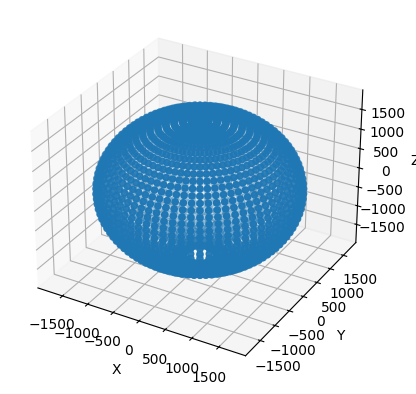

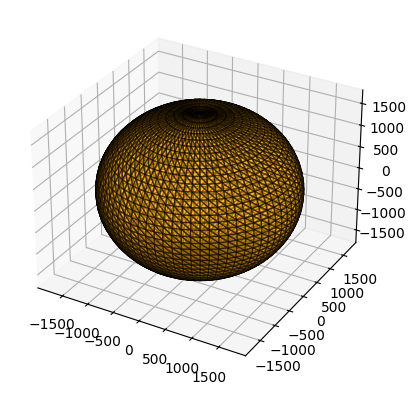

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

points = np.array(points)
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]
ax.scatter(x, y, z)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

triangles = [ [points[tri[0]], points[tri[1]], points[tri[2]]]  for tri in tris]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

poly = Poly3DCollection(triangles, alpha=0.5, facecolor='orange', edgecolor='k')
ax.add_collection3d(poly)

# ax.set_xlim(0,1)
# ax.set_ylim(0,1)
# ax.set_zlim(0,1)

plt.show()

In [ ]:
unrotated_sat_pos = np.zeros((num_gps_sats, 3))
for i in range(num_gps_sats):
    unrotated_sat_pos[i][0] = earth_to_moon_dist
    unrotated_sat_pos[i][1] = earth_rad * np.sin(i * 2 * np.pi / num_gps_sats)
    unrotated_sat_pos[i][2] = earth_rad * np.cos(i * 2 * np.pi / num_gps_sats)
    print(unrotated_sat_pos[i])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

points = np.array(points)
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]
ax.scatter(x, y, z)

x2 = unrotated_sat_pos[:, 0]
y2 = unrotated_sat_pos[:, 1]
z2 = unrotated_sat_pos[:, 2]
ax.scatter(x2, y2, z2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# ax.set_xlim(-400000, 400000)
# ax.set_ylim(-400000, 400000)
# ax.set_zlim(-400000, 400000)

plt.show()

In [ ]:
## Ray tracing math:
# def intersect_triangle(points, tri, origin, ray):
#     p1 = points[tri[0]]
#     p2 = points[tri[1]]
#     p3 = points[tri[2]]
#     p12 = p2 - p1
#     p13 = p3 - p1
#     n = np.cross(p12, p13)
#     n_norm = n / np.linalg.norm(n)

#     d = -1 * np.dot(n_norm, p1)
#     vec_dot = np.vectorize(np.dot, signature='(n),(m)->()')
#     t = - (vec_dot(n_, O) + d)/vec_dot(n_norm, e_) 

## Get random satellite positions:
# moon_radius = 1737.4  # km
# earth_to_moon_dist = 384399 # km
# num_gps_sats = 30
# earth_ang = 0 # deg
# gps_rad = 20180 #km

def check_number_of_intersections(test_points, points, tris, satellites):
    num_rays = np.zeros(img_height * img_width + 2)
    for i in tqdm(range(len(test_points))):
        p = test_points[i]
        num_rays[i] = num_gps_sats
        origin = p + p / np.linalg.norm(p)
        #print("Point =", p, "; origin = ", origin)
        for sat in satellites:
            dir = sat - origin
            for tri in tris:
                v0 = points[tri[0]]
                v1 = points[tri[1]]
                v2 = points[tri[2]]
                _, hits, _ = ray_triangle_intersect(origin, dir, v0, v1, v2)
                if hits:
                    num_rays[i] -= 1
                    #print("Found intersection")
                    break
        #print(num_rays[i])
    return num_rays

test_points = [[-5000, 0, 0], [5000, 0, 0], [1, 1, 1], [0,0,1800], [0,0,-1800]]
print(check_number_of_intersections(test_points,points, tris, unrotated_sat_pos))

In [ ]:
num_rays = check_number_of_intersections(points, points, tris, unrotated_sat_pos)
print(num_rays)

In [ ]:
def get_next_filename(base_name, ext):
    """
    Returns a filename like 'base_name.ext', 'base_name_1.ext', etc.,
    that doesn't already exist.
    """
    filename = f"{base_name}.{ext}"
    i = 1
    while os.path.exists(filename):
        filename = f"{base_name}_{i}.{ext}"
        i += 1
    return filename

def write_output_tiff():
    output_filename = get_next_filename("output", "tiff")
    input = tifffile.imread(input_filename)
    output = np.zeros((input.shape[0], input.shape[1], 3))
    minValue = np.min(input)
    maxValue = np.max(input)
    print(minValue)
    print(maxValue)
    print(input.shape[0])
    print(input.shape[1])
    for i in range(input.shape[1]):
        for j in range(input.shape[0]):
            index = get_index(int(np.floor(i / downsample_ratio)), int(np.floor(j / downsample_ratio) + 1))
            #print(int(np.floor(i / downsample_ratio)), ", ", (int(np.floor(j / downsample_ratio)) + 1), "-->", index)
            #print(index)
            num_visible = num_rays[index]
            rgb_val = (input[j][i] - minValue) / (maxValue - minValue)
            if num_visible == 0:
                output[j][i][0] = rgb_val
            elif num_visible == num_gps_sats:
                output[j][i][1] = rgb_val
            else:
                output[j][i][2] = rgb_val
    tifffile.imwrite(output_filename, output, photometric='rgb')
    return output_filename

output_filename = write_output_tiff()
img = tifffile.imread(output_filename)

# Display
plt.imshow(img)
plt.axis('off')  # optional, remove axes
plt.show()